# Employee Analytics

## Objective
Analyze employee salary, experience, and department data using:
- NumPy
- Pandas
- Matplotlib
- Seaborn

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset Creation

In [ ]:
np.random.seed(10)

df = pd.DataFrame({
    "employee_id": range(1, 501),

    "experience_years": np.random.randint(0, 20, 500),

    "salary": np.random.randint(20000, 150000, 500),

    "performance_rating": np.random.randint(1, 6, 500),

    "department": np.random.choice(
        ["IT", "HR", "Sales", "Finance"],
        500
    )
})



In [ ]:
df.head()

,employee_id,experience_years,salary,performance_rating,department
0,1,9,62081,5,Finance
1,2,4,120202,5,IT
2,3,15,109651,3,Finance
3,4,0,70175,2,HR
4,5,17,59493,2,Finance


# Dataset Inspection

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   employee_id         500 non-null    int64 
 1   experience_years    500 non-null    int64 
 2   salary              500 non-null    int64 
 3   performance_rating  500 non-null    int64 
 4   department          500 non-null    object
dtypes: int64(4), object(1)
memory usage: 19.7+ KB


In [ ]:
df.describe(include="all")


,employee_id,experience_years,salary,performance_rating,department
count,500.000000,500.000000,500.000000,500.000000,500
unique,NaN,NaN,NaN,NaN,4
top,NaN,NaN,NaN,NaN,HR
freq,NaN,NaN,NaN,NaN,128
mean,250.500000,9.768000,85734.504000,2.974000,NaN
std,144.481833,5.896415,37764.998663,1.421748,NaN
min,1.000000,0.000000,20135.000000,1.000000,NaN
25%,125.750000,5.000000,53242.000000,2.000000,NaN
50%,250.500000,10.000000,86474.000000,3.000000,NaN
75%,375.250000,15.000000,118165.250000,4.000000,NaN


# Department Salary Analysis

In [ ]:
df.groupby("department").agg(["mean","median","max"])

employee_id             experience_years                   salary  \
                  mean median  max             mean median max          mean   
department                                                                     
Finance     244.347107  222.0  497         9.685950   10.0  19  81765.471074   
HR          250.320312  248.0  493         9.546875   10.0  19  89800.867188   
IT          260.095238  271.0  499        10.230159   10.0  19  85814.166667   
Sales       246.968000  241.0  500         9.608000    9.0  19  85332.272000   

                            performance_rating             
             median     max               mean median max  
department                                                 
Finance     78103.0  149792           2.966942    3.0   5  
HR          94153.5  149927           2.898438    3.0   5  
IT          79562.5  149722           2.976190    3.0   5  
Sales       87230.0  149897           3.056000    3.0   5

# Pivot Table Analysis

In [ ]:
pd.pivot_table(
    df,

    values="salary",

    index="department",

    columns="performance_rating",
    aggfunc="mean"
)

performance_rating,1,2,3,4,5
department,,,,,
Finance,82720.923077,76804.807692,83619.500000,82036.041667,84187.920000
HR,97866.692308,90268.281250,85418.960000,79886.210526,92618.461538
IT,90444.909091,79540.033333,91832.444444,79517.652174,88675.583333
Sales,85739.111111,102458.947368,89882.800000,75612.714286,78485.846154


# Salary Ranking

In [ ]:
df["salary_rank"]=df["salary"].rank(ascending=False)

In [ ]:
df.head()

,employee_id,experience_years,salary,performance_rating,department,salary_rank
0,1,9,62081,5,Finance,348.0
1,2,4,120202,5,IT,119.0
2,3,15,109651,3,Finance,167.0
3,4,0,70175,2,HR,307.0
4,5,17,59493,2,Finance,360.0


# Employee Level Classification

In [ ]:
df["level"] = np.where(
    df["experience_years"] >= 10,
    "Senior",
    "Junior"
)

df.head()

,employee_id,experience_years,salary,performance_rating,department,salary_rank,level
0,1,9,62081,5,Finance,348.0,Junior
1,2,4,120202,5,IT,119.0,Junior
2,3,15,109651,3,Finance,167.0,Senior
3,4,0,70175,2,HR,307.0,Junior
4,5,17,59493,2,Finance,360.0,Senior


# Department Distribution

In [ ]:
df["department"].value_counts(normalize=True)

,proportion
department,
HR,0.256
IT,0.252
Sales,0.250
Finance,0.242


#Visualization

# Salary Distribution

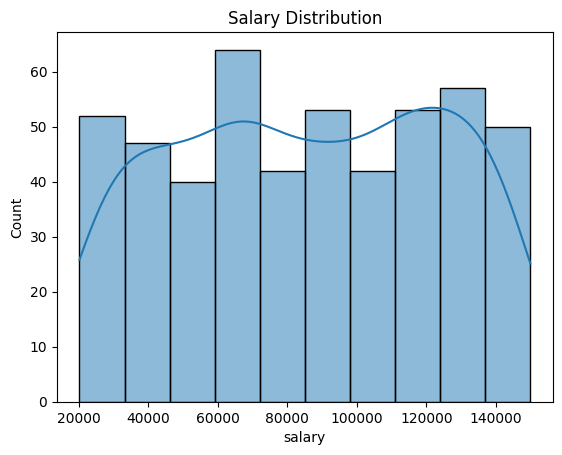

In [ ]:
sns.histplot(df["salary"], kde=True)

plt.title("Salary Distribution")

plt.show()

# Experience vs Salary

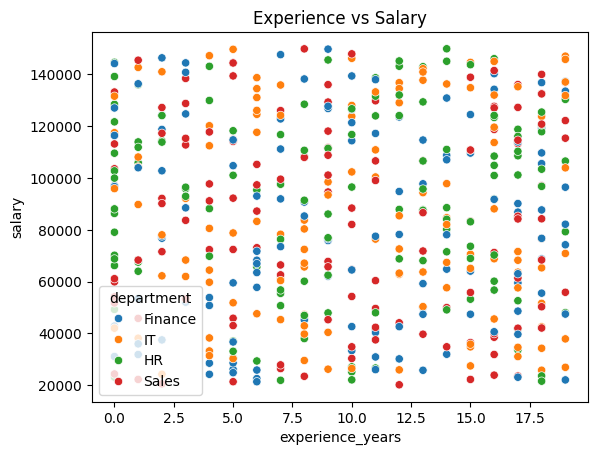

In [ ]:
sns.scatterplot(
    x="experience_years",
    y="salary",
    hue="department",
    data=df
)

plt.title("Experience vs Salary")

plt.show()

# Salary Spread by Department

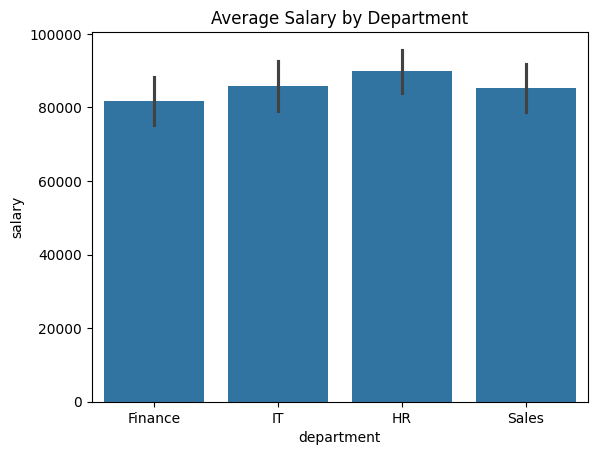

In [ ]:
sns.barplot(
    x="department",
    y="salary",
    data=df
)

plt.title("Average Salary by Department")

plt.show()

# Salary Spread by Department

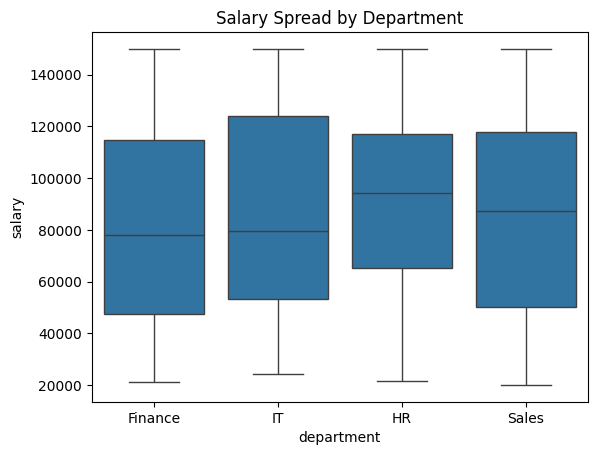

In [ ]:
sns.boxplot(
    x="department",
    y="salary",
    data=df
)

plt.title("Salary Spread by Department")

plt.show()